# Estimación de Edad con CNNs — Enfoque en DataLoaders

> **Objetivo pedagógico:** Entender a fondo cómo funciona el pipeline de datos en PyTorch:  
> `Disco → Dataset → DataLoader → Modelo → Loss`
>
> La arquitectura CNN aquí es **intencionalmente simple** (baseline).  
> Tu tarea será modificarla para mejorar el desempeño.

---

## ¿Qué es un DataLoader y por qué importa?

Cuando tienes 20,000 imágenes **no puedes** cargarlas todas en memoria a la vez.  
PyTorch resuelve esto con dos abstracciones que trabajan juntas:

```
┌─────────────────────────────────────────────────────────────┐
│  DISCO                                                      │
│  dataset/train/  25_0_0_20170116.jpg                       │
│                  32_1_2_20170210.jpg  ...20k archivos       │
└────────────────────┬────────────────────────────────────────┘
                     │  lee solo lo necesario
                     ▼
┌─────────────────────────────────────────────────────────────┐
│  Dataset   (torch.utils.data.Dataset)                       │
│  Sabe cómo leer UN ejemplo: imagen + etiqueta               │
│  dataset[42]  →  (tensor_imagen, edad_float)                │
└────────────────────┬────────────────────────────────────────┘
                     │  agrupa en lotes
                     ▼
┌─────────────────────────────────────────────────────────────┐
│  DataLoader  (torch.utils.data.DataLoader)                  │
│  • Shuffle aleatorio cada época                             │
│  • Agrupa N ejemplos en un batch                            │
│  • Paraleliza la lectura (num_workers)                      │
│  → (batch_imagenes [N,C,H,W], batch_edades [N])            │
└────────────────────┬────────────────────────────────────────┘
                     │
                     ▼
               Modelo → Loss
```

---

## 0. Importaciones y configuración global

In [63]:
import os
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from PIL import Image

# ─── Configuración ────────────────────────────────────────────────────────────
DATA_DIR   = Path("dataset")   # carpeta con train/ val/ test/
IMG_SIZE   = 128                # resolución a la que redimensionamos (64×64)
BATCH_SIZE = 32                # imágenes por lote de 32-128, intentar con 64 y comparar
NUM_EPOCHS = 5                 # épocas de entrenamiento
LR         = 1e-3              # learning rate
NUM_WORKERS = 3                # hilos paralelos para leer imágenes
                               # (en Lightning Studio puedes subir a 4–8)

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Dispositivo
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cpu


---
## 1. Dataset personalizado

### ¿Qué es `torch.utils.data.Dataset`?

Es una clase abstracta de PyTorch. Para usarla debemos heredar de ella e implementar **exactamente 3 métodos**:

| Método | ¿Para qué sirve? |
|---|---|
| `__init__` | Inicializa la lista de rutas y etiquetas (¡NO carga imágenes!) |
| `__len__` | Retorna cuántos ejemplos tiene el dataset |
| `__getitem__(idx)` | Carga y retorna **un solo** ejemplo: (imagen, etiqueta) |

> **Regla de oro:** `__init__` solo guarda metadatos.  
> `__getitem__` es el que realmente toca disco — y solo cuando se necesita.

In [51]:
class AgeDataset(Dataset):
    """
    Dataset para imágenes con etiqueta de edad en el nombre de archivo.
    Formato esperado: [age]_[gender]_[race]_[datetime].jpg
    Ejemplo:          25_0_2_20170116174525125.jpg
    """

    def __init__(self, root_dir: Path, transform=None):
        """
        Args:
            root_dir  : ruta a la carpeta (ej: dataset/train)
            transform : transformaciones a aplicar a cada imagen
        """
        self.transform = transform

        # ── Paso 1: recolectar rutas y parsear etiquetas ───────────────────────
        # Esto ocurre UNA SOLA VEZ al crear el dataset.
        # Solo guardamos strings/números en memoria, NO píxeles.
        EXTENSIONS = {".jpg", ".jpeg", ".png"}
        self.samples = []  # lista de tuplas (path, age_float)

        for img_path in Path(root_dir).iterdir():
            if img_path.suffix.lower() not in EXTENSIONS:
                continue
            age = self._parse_age(img_path.name)
            if age is not None:            # descarta archivos con nombre inválido
                self.samples.append((img_path, float(age)))

        print(f"  [{root_dir.name}] {len(self.samples):,} imágenes cargadas")

    @staticmethod
    def _parse_age(filename: str):
        """
        Extrae la edad del nombre de archivo.
        '25_0_2_20170116.jpg'  →  25
        Retorna None si el formato no coincide.
        """
        match = re.match(r'^(\d+)_', filename)
        if match:
            age = int(match.group(1))
            if 0 <= age <= 116:            # filtro de sanidad
                return age
        return None

    # ── Los 2 métodos obligatorios ─────────────────────────────────────────────

    def __len__(self):
        """PyTorch llama esto para saber cuántos ejemplos hay."""
        return len(self.samples)

    def __getitem__(self, idx):
        """
        PyTorch llama esto para obtener el ejemplo número `idx`.
        Este es el único momento en que tocamos el disco.

        Retorna:
            image  : Tensor [C, H, W]  (float32)
            age    : Tensor escalar     (float32)
        """
        img_path, age = self.samples[idx]

        # Leer imagen del disco
        image = Image.open(img_path).convert("RGB")

        # Aplicar transformaciones (resize, normalizar, augmentations...)
        if self.transform:
            image = self.transform(image)

        # La etiqueta debe ser float32 para regresión con MSELoss
        return image, torch.tensor(age, dtype=torch.float32)

---
## 2. Transformaciones (preprocesamiento)

Las transformaciones se aplican dentro de `__getitem__`, imagen por imagen,  
justo antes de entregarla al modelo. Esto permite hacer **data augmentation** sin guardar copias.

```
Imagen en disco  →  transform  →  Tensor normalizado
```

> **Convención importante:**  
> `Normalize(mean, std)` usa los valores estándar de ImageNet (RGB).  
> El modelo espera que los píxeles estén en ese rango — no en [0, 255].

In [64]:
# Valores de media y std de ImageNet (estándar para modelos pre-entrenados)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Transformación para ENTRENAMIENTO ─────────────────────────────────────────
# train_transform y val_transform son objetos por lo que se usan para aplicar las transformaciones pertinentes en cada subcarpeta
# Incluye augmentations para que el modelo vea variedad artificial
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),   # redimensionar a 64×64
    transforms.RandomHorizontalFlip(p=0.5),   # espejo horizontal aleatorio
    transforms.ColorJitter(                   # variaciones de color leves
        brightness=0.2, contrast=0.2),
    transforms.ToTensor(),                    # PIL Image [H,W,C] → Tensor [C,H,W], valores [0,1]
    transforms.Normalize(IMAGENET_MEAN,       # normalizar con media/std de ImageNet
                         IMAGENET_STD),
])

# ── Transformación para VALIDACIÓN y TEST ─────────────────────────────────────
# Sin augmentation: queremos evaluar con datos limpios y consistentes
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transformaciones definidas ✓")
print(f"  Train: Resize → Flip → ColorJitter → ToTensor → Normalize")
print(f"  Val  : Resize → ToTensor → Normalize")

Transformaciones definidas ✓
  Train: Resize → Flip → ColorJitter → ToTensor → Normalize
  Val  : Resize → ToTensor → Normalize


---
## 3. Crear los Datasets

Instanciamos `AgeDataset` para cada split.  
Recuerda: esto **solo construye la lista de rutas**, no carga imágenes.

In [40]:
print("Construyendo datasets...")
# acá se aplican los métodos obligatorios de la clase __init__ y __len__, 
# recorriendo todos(Tensor_procesado, Tensor_escalar) las imagenes de subcarpeta, añadiendolas a self.samples 
# y asignando el tranfrom que se le aplica a cada una
train_dataset = AgeDataset(DATA_DIR / "train", transform=train_transform)
val_dataset   = AgeDataset(DATA_DIR / "val",   transform=val_transform)
test_dataset  = AgeDataset(DATA_DIR / "test",  transform=val_transform)

print(f"\nTotal: {len(train_dataset) + len(val_dataset) + len(test_dataset):,} imágenes")

Construyendo datasets...
  [train] 16,874 imágenes cargadas
  [val] 3,615 imágenes cargadas
  [test] 3,617 imágenes cargadas

Total: 24,106 imágenes


---
## 4. Explorar un ejemplo del Dataset

Antes de entrenar, siempre vale la pena inspeccionar qué devuelve `__getitem__`.

In [41]:
# Inspeccionar un solo ejemplo
# train_dataset[0] ejecuta getitem(0) -> carga imagen, transforma y retorna imagen y torch.tensor(age)
# train_dataset[0] = (Tensor_procesado, Tensor_escalar)
# train_dataset.samples -> conjunto de tuplas (url, age)

sample_img, sample_age = train_dataset[0]

print("=== Un ejemplo del Dataset ===")
print(f"  Tipo imagen : {type(sample_img)}")
print(f"  Shape       : {sample_img.shape}   ← [Canales, Alto, Ancho]")
print(f"  Dtype       : {sample_img.dtype}")
print(f"  Min / Max   : {sample_img.min():.3f} / {sample_img.max():.3f}  ← ya normalizado")
print(f"  Etiqueta    : {sample_age.item()} años")

=== Un ejemplo del Dataset ===
  Tipo imagen : <class 'torch.Tensor'>
  Shape       : torch.Size([3, 128, 128])   ← [Canales, Alto, Ancho]
  Dtype       : torch.float32
  Min / Max   : -2.118 / 2.413  ← ya normalizado
  Etiqueta    : 33.0 años


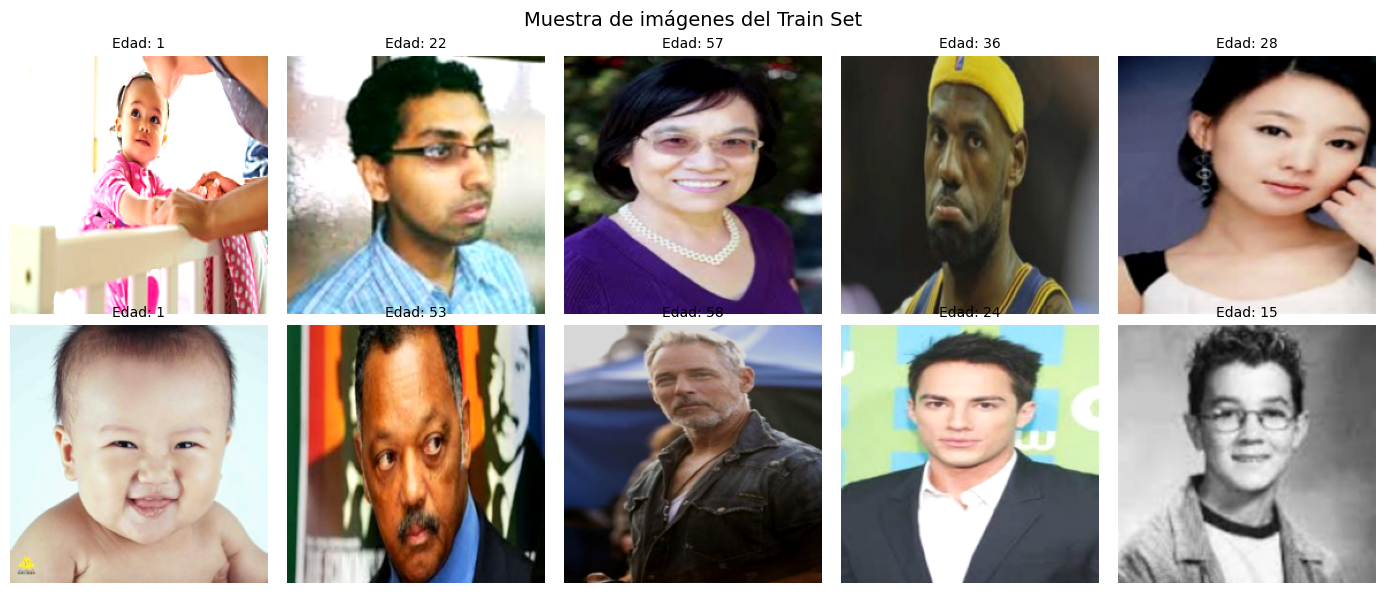

In [11]:
# Visualizar algunas imágenes del train set
# Debemos DENORMALIZAR para que se vean bien
def denormalize(tensor):
    """Revierte la normalización para visualizar."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Muestra de imágenes del Train Set", fontsize=14)

indices = np.random.choice(len(train_dataset), 10, replace=False)
for ax, idx in zip(axes.flat, indices):
    img_t, age = train_dataset[idx]
    img_vis = denormalize(img_t).permute(1, 2, 0).numpy()  # [C,H,W] → [H,W,C]
    ax.imshow(img_vis)
    ax.set_title(f"Edad: {int(age.item())}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

---
## 5. Crear los DataLoaders

### ¿Qué hace el DataLoader exactamente?

El `DataLoader` envuelve al `Dataset` y se encarga de:

| Parámetro | ¿Qué controla? | Recomendación |
|---|---|---|
| `batch_size` | Cuántas imágenes por lote | 32–64 para GPUs moderadas |
| `shuffle` | ¿Mezclar al inicio de cada época? | `True` en train, `False` en val/test |
| `num_workers` | Procesos paralelos de lectura | 2–8 según CPU disponible |
| `pin_memory` | Pre-alocar memoria para GPU | `True` si usas CUDA |
| `drop_last` | ¿Descartar el último batch incompleto? | Opcional |

> **`num_workers > 0`**: PyTorch lanza procesos en paralelo que pre-cargan el siguiente batch  
> mientras el modelo procesa el actual. Esto elimina el cuello de botella de I/O.

In [65]:
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,         # ← IMPORTANTE en train: mezcla cada época
    num_workers = NUM_WORKERS,  # lectura paralela del disco
    pin_memory  = DEVICE.type == "cuda",  # acelera transferencia CPU→GPU
    drop_last   = True,         # descarta el último batch si es menor a BATCH_SIZE
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,        # ← NUNCA mezclar en val/test
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE.type == "cuda",
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = DEVICE.type == "cuda",
)

# ── Información útil ──────────────────────────────────────────────────────────
print("DataLoaders creados ✓")
print(f"  Train → {len(train_loader)} batches × {BATCH_SIZE} imgs")
print(f"  Val   → {len(val_loader)} batches × {BATCH_SIZE} imgs")
print(f"  Test  → {len(test_loader)} batches × {BATCH_SIZE} imgs")

DataLoaders creados ✓
  Train → 527 batches × 32 imgs
  Val   → 113 batches × 32 imgs
  Test  → 114 batches × 32 imgs


In [54]:
# ── Inspeccionar un batch completo ────────────────────────────────────────────
# Esto es lo que el modelo recibe en cada iteración del loop de entrenamiento
batch_imgs, batch_ages = next(iter(train_loader))

print("=== Un batch del DataLoader ===")
print(f"  batch_imgs.shape : {batch_imgs.shape}")
print(f"                      └─ [batch_size={BATCH_SIZE}, canales=3, H={IMG_SIZE}, W={IMG_SIZE}]")
print(f"  batch_ages.shape : {batch_ages.shape}")
print(f"                      └─ [batch_size={BATCH_SIZE}] — una edad por imagen")
print(f"  Edades en el batch: {batch_ages[:8].int().tolist()} ...")

=== Un batch del DataLoader ===
  batch_imgs.shape : torch.Size([32, 3, 128, 128])
                      └─ [batch_size=32, canales=3, H=128, W=128]
  batch_ages.shape : torch.Size([32])
                      └─ [batch_size=32] — una edad por imagen
  Edades en el batch: [26, 50, 42, 74, 36, 26, 68, 26] ...


---
## 6. Modelo CNN (baseline simple)

> **Nota pedagógica:** Este modelo es un *baseline* intencional.  
> Tiene solo 3 bloques convolucionales y una cabeza de regresión lineal.  
> Tu tarea será modificarlo para mejorar el MAE.

**Ideas para mejorar (no implementadas aquí):**
- Agregar más bloques conv con más filtros
- Usar BatchNormalization después de cada conv
- Añadir Dropout para regularización
- Aumentar `IMG_SIZE` a 128 o 224
- Usar un modelo pre-entrenado (ResNet, EfficientNet) como backbone

In [66]:
class SimpleCNN(nn.Module):
    """
    CNN mínima para regresión de edad.

    Arquitectura (para IMG_SIZE=128):
      [3, 128, 128] → Conv1 → BatchNorm → ReLU → MaxPool → [16, 64, 64]
                    → Conv2 → BatchNorm → ReLU → MaxPool → [32, 32, 32]
                    → Conv3 → BatchNorm → ReLU → MaxPool → [64, 16, 16]
                    → Conv4 → BatchNorm → ReLU → MaxPool → [128, 8, 8]
                    → Flatten                             → [128*8*8 = 16384]
                    → FC1   → ReLU                        → [128]
                    → FC2                                 → [1]  ← predicción de edad
    """

    def __init__(self):
        super().__init__()

        # ── Bloques convolucionales ────────────────────────────────────────────
        # Patrón: Conv2d → BatchNorm2d → ReLU → MaxPool2d
        # Conv2d(in_channels, out_channels, kernel_size, padding)
        self.features = nn.Sequential(
            # Bloque 1: extrae bordes y texturas básicas
            nn.Conv2d(3, 16, kernel_size=3, padding=1),   # [3,128,128] → [16,128,128]
            nn.BatchNorm2d(16),                           # Normaliza 16 canales
            nn.ReLU(),
            nn.MaxPool2d(2),                              # [16,128,128] → [16,64,64]

            # Bloque 2: patrones más complejos
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # [16,64,64] → [32,64,64]
            nn.BatchNorm2d(32),                           # Normaliza 32 canales (CORRECTO)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # [32,64,64] → [32,32,32]

            # Bloque 3: características de alto nivel
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # [32,32,32] → [64,32,32]
            nn.BatchNorm2d(64),                           # Normaliza 64 canales (CORRECTO)
            nn.ReLU(),
            nn.MaxPool2d(2), 
                                         
            # Bloque 4: características muy abstractas
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # [64,16,16] → [128,16,16]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                               # [64,32,32] → [64,16,16]
        )

        # ── Cabeza de regresión ────────────────────────────────────────────────
        # Aplana el mapa de features y predice un único valor (la edad)
        self.regressor = nn.Sequential(
            nn.Flatten(),              # [64,16,16] → [16384]
            nn.Linear(128 * 8 * 8, 128),  # 16384 → 128 (CORRECTO)
            nn.ReLU(),
            nn.Linear(128, 1),         # salida: un número = edad predicha
        )

    def forward(self, x):
        """
        x: [batch_size, 3, 64, 64]
        retorna: [batch_size, 1]
        """
        x = self.features(x)
        x = self.regressor(x)
        return x


model = SimpleCNN().to(DEVICE)
print(model)

# Contar parámetros entrenables
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParámetros entrenables: {total_params:,}")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [67]:
# ── Verificar que el forward pass funciona ────────────────────────────────────
with torch.no_grad():
    dummy = torch.randn(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out = model(dummy)
    print(f"Input shape : {dummy.shape}")
    print(f"Output shape: {out.shape}   ← [batch_size, 1]")

Input shape : torch.Size([32, 3, 128, 128])
Output shape: torch.Size([32, 1])   ← [batch_size, 1]


---
## 7. Función de pérdida y optimizador

Para **regresión** (predecir un número continuo como la edad) usamos:

- **Loss: MSELoss** — Mean Squared Error: $\mathcal{L} = \frac{1}{N}\sum(\hat{y}_i - y_i)^2$  
  Penaliza errores grandes de forma cuadrática.

- **Métrica de evaluación: MAE** — Mean Absolute Error: $\frac{1}{N}\sum|\hat{y}_i - y_i|$  
  Más interpretable: el modelo se equivoca X años en promedio.

> MSELoss como función de pérdida durante el entrenamiento  
> MAE como métrica para reportar resultados (más legible)

In [46]:
criterion = nn.MSELoss()                          # función de pérdida (para backprop)
optimizer = optim.Adam(model.parameters(), lr=LR) # actualiza los pesos

# Scheduler: reduce LR si la val_loss no mejora en 3 épocas
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

def compute_mae(predictions, targets):
    """Mean Absolute Error — interpretable en 'años'."""
    return torch.abs(predictions - targets).mean().item()

print(f"Loss     : MSELoss")
print(f"Métrica  : MAE (años)")
print(f"Optimizer: Adam  lr={LR}")
print(f"Scheduler: ReduceLROnPlateau (patience=3)")

Loss     : MSELoss
Métrica  : MAE (años)
Optimizer: Adam  lr=0.001
Scheduler: ReduceLROnPlateau (patience=3)


---
## 8. Loop de entrenamiento

### Anatomía del loop

```
for epoch in range(NUM_EPOCHS):

    # ── FASE TRAIN ──────────────────────────────────────────
    model.train()                   # activa Dropout, BatchNorm en modo train
    for batch_imgs, batch_ages in train_loader:
        optimizer.zero_grad()       # limpia gradientes del paso anterior
        preds = model(batch_imgs)   # forward pass
        loss  = criterion(preds, batch_ages)  # calcula pérdida
        loss.backward()             # backpropagation
        optimizer.step()            # actualiza pesos

    # ── FASE VALIDACIÓN ─────────────────────────────────────
    model.eval()                    # desactiva Dropout, BatchNorm en modo eval
    with torch.no_grad():           # no calcular gradientes (ahorra memoria)
        for batch_imgs, batch_ages in val_loader:
            preds = model(batch_imgs)
            ...                     # acumular métricas
```

In [68]:
history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

best_val_mae  = float("inf")
best_model_path = "best_model.pth"

print(f"{'Época':>5} | {'Train Loss':>10} | {'Train MAE':>9} | {'Val Loss':>8} | {'Val MAE':>7}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):

    # ────────────────────────────── FASE ENTRENAMIENTO ───────────────────────
    model.train()
    train_loss_accum = 0.0
    train_mae_accum  = 0.0

    for batch_imgs, batch_ages in train_loader:
        # Mover datos al dispositivo (CPU o GPU)
        batch_imgs = batch_imgs.to(DEVICE)
        batch_ages = batch_ages.to(DEVICE)

        # 1. Limpiar gradientes acumulados del paso anterior
        optimizer.zero_grad()

        # 2. Forward pass: el modelo predice edades
        preds = model(batch_imgs).squeeze(1)  # [B,1] → [B]

        # 3. Calcular pérdida
        loss = criterion(preds, batch_ages)

        # 4. Backward pass: calcular gradientes
        loss.backward()

        # 5. Actualizar pesos
        optimizer.step()

        train_loss_accum += loss.item()
        train_mae_accum  += compute_mae(preds, batch_ages)

    train_loss = train_loss_accum / len(train_loader)
    train_mae  = train_mae_accum  / len(train_loader)

    # ────────────────────────────── FASE VALIDACIÓN ──────────────────────────
    model.eval()
    val_loss_accum = 0.0
    val_mae_accum  = 0.0

    with torch.no_grad():           # sin gradientes → más rápido y menos memoria
        for batch_imgs, batch_ages in val_loader:
            batch_imgs = batch_imgs.to(DEVICE)
            batch_ages = batch_ages.to(DEVICE)

            preds = model(batch_imgs).squeeze(1)
            loss  = criterion(preds, batch_ages)

            val_loss_accum += loss.item()
            val_mae_accum  += compute_mae(preds, batch_ages)

    val_loss = val_loss_accum / len(val_loader)
    val_mae  = val_mae_accum  / len(val_loader)

    # Actualizar scheduler
    scheduler.step(val_loss)

    # Guardar mejor modelo
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), best_model_path)
        best_marker = " ← mejor"
    else:
        best_marker = ""

    # Guardar historial
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)

    print(f"{epoch:>5} | {train_loss:>10.2f} | {train_mae:>9.2f} | {val_loss:>8.2f} | {val_mae:>7.2f}{best_marker}")

print(f"\nMejor Val MAE: {best_val_mae:.2f} años")

Época | Train Loss | Train MAE | Val Loss | Val MAE
-------------------------------------------------------


    1 |    1493.31 |     32.96 |  1494.47 |   33.03 ← mejor
    2 |    1492.42 |     32.94 |  1494.05 |   33.03 ← mejor
    3 |    1492.64 |     32.95 |  1494.34 |   33.03
    4 |    1492.89 |     32.95 |  1494.25 |   33.03
    5 |    1492.96 |     32.95 |  1494.44 |   33.03

Mejor Val MAE: 33.03 años


---
## 9. Visualizar curvas de aprendizaje

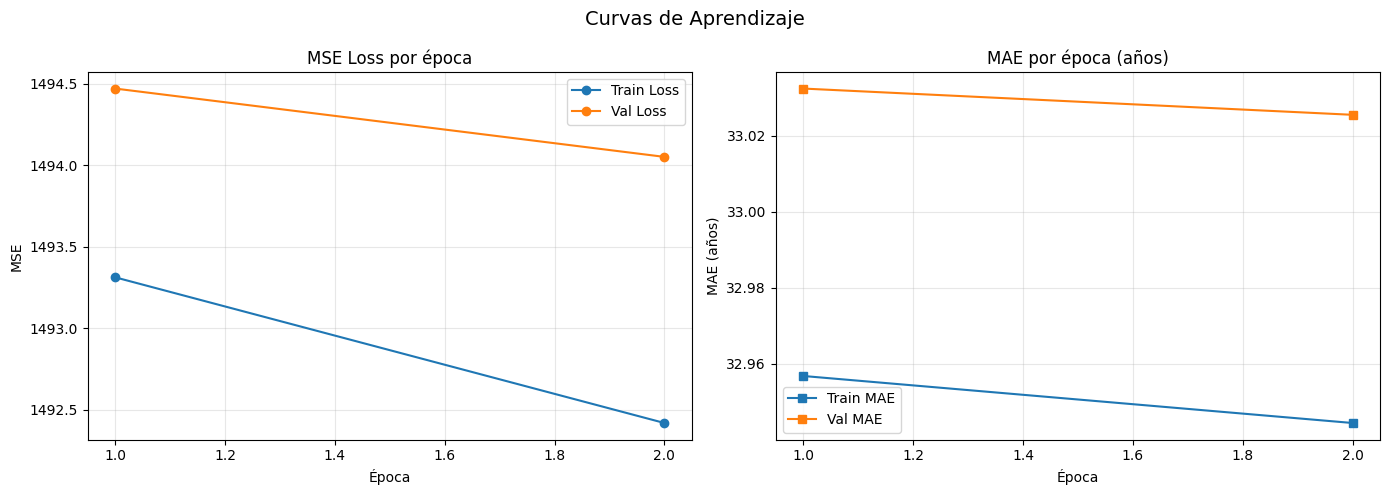


Diagnóstico final:
  Train MAE : 32.94 años
  Val MAE   : 33.03 años
  Gap       : 0.08 años  → Posible UNDERFITTING (considera más capas, más filtros o más épocas)


In [61]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Curvas de Aprendizaje", fontsize=14)

# Loss
ax1.plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
ax1.plot(epochs_range, history["val_loss"],   label="Val Loss",   marker="o")
ax1.set_title("MSE Loss por época")
ax1.set_xlabel("Época"); ax1.set_ylabel("MSE")
ax1.legend(); ax1.grid(True, alpha=0.3)

# MAE
ax2.plot(epochs_range, history["train_mae"], label="Train MAE", marker="s")
ax2.plot(epochs_range, history["val_mae"],   label="Val MAE",   marker="s")
ax2.set_title("MAE por época (años)")
ax2.set_xlabel("Época"); ax2.set_ylabel("MAE (años)")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnóstico rápido
gap = history["val_mae"][-1] - history["train_mae"][-1]
print(f"\nDiagnóstico final:")
print(f"  Train MAE : {history['train_mae'][-1]:.2f} años")
print(f"  Val MAE   : {history['val_mae'][-1]:.2f} años")
print(f"  Gap       : {gap:.2f} años", end="  ")
if gap > 3:
    print("→ Posible OVERFITTING (considera Dropout, menos capacidad o más datos)")
elif history["train_mae"][-1] > 8:
    print("→ Posible UNDERFITTING (considera más capas, más filtros o más épocas)")
else:
    print("→ Buen balance")

---
## 10. Evaluación final en Test Set

> El test set se usa **una sola vez** al final.  
> Usarlo durante el desarrollo introduce sesgo en las decisiones del modelo.

In [69]:
# Cargar el mejor modelo guardado
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds  = []
all_targets = []

with torch.no_grad():
    for batch_imgs, batch_ages in test_loader:
        batch_imgs = batch_imgs.to(DEVICE)
        preds = model(batch_imgs).squeeze(1).cpu()
        all_preds.extend(preds.tolist())
        all_targets.extend(batch_ages.tolist())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

test_mae  = np.abs(all_preds - all_targets).mean()
test_rmse = np.sqrt(((all_preds - all_targets) ** 2).mean())

print("=== Resultados en Test Set ===")
print(f"  MAE  : {test_mae:.2f} años")
print(f"  RMSE : {test_rmse:.2f} años")

=== Resultados en Test Set ===
  MAE  : 33.15 años
  RMSE : 38.72 años


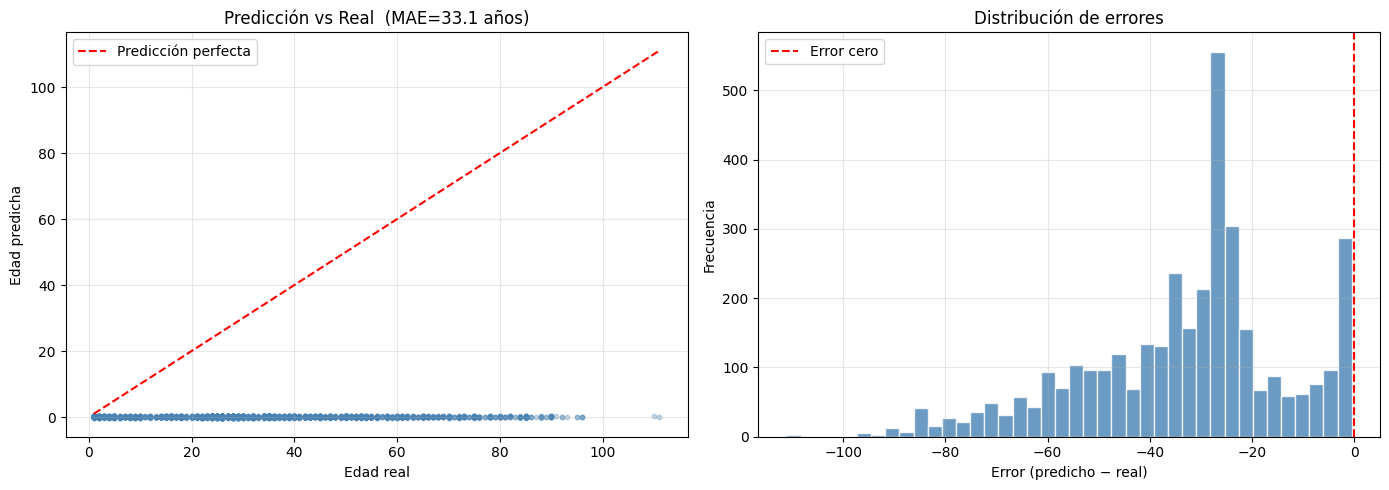

In [70]:
# Scatter: predicciones vs valores reales
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
ax1.scatter(all_targets, all_preds, alpha=0.3, s=10, color="steelblue")
min_age, max_age = int(all_targets.min()), int(all_targets.max())
ax1.plot([min_age, max_age], [min_age, max_age], 'r--', label="Predicción perfecta")
ax1.set_xlabel("Edad real"); ax1.set_ylabel("Edad predicha")
ax1.set_title(f"Predicción vs Real  (MAE={test_mae:.1f} años)")
ax1.legend(); ax1.grid(True, alpha=0.3)

# Histograma de errores
errors = all_preds - all_targets
ax2.hist(errors, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
ax2.axvline(0, color='red', linestyle='--', label="Error cero")
ax2.set_xlabel("Error (predicho − real)"); ax2.set_ylabel("Frecuencia")
ax2.set_title("Distribución de errores")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 11. Inferencia sobre una sola imagen

Cómo usar el modelo entrenado para predecir la edad de una imagen nueva.

In [ ]:
def predict_age(img_path: str, model, transform, device) -> float:
    """
    Predice la edad de una imagen.
    
    Args:
        img_path  : ruta al archivo de imagen
        model     : modelo entrenado (en modo eval)
        transform : mismas transformaciones que en validación
        device    : cpu o cuda
    """
    model.eval()
    image = Image.open(img_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)  # [C,H,W] → [1,C,H,W]

    with torch.no_grad():
        pred = model(tensor).squeeze().item()

    return round(pred, 1)


# Probar con una imagen del test set
sample_path, sample_real_age = test_dataset.samples[0]
predicted_age = predict_age(sample_path, model, val_transform, DEVICE)

print(f"Imagen   : {sample_path.name}")
print(f"Edad real: {int(sample_real_age)} años")
print(f"Predicha : {predicted_age} años")
print(f"Error    : {abs(predicted_age - sample_real_age):.1f} años")

---
## 12. Resumen y próximos pasos

### Lo que construimos hoy

```
AgeDataset          →   DataLoader          →   SimpleCNN       →   MSELoss
  __init__: rutas       batch_size=32           3 conv blocks       MAE en test
  __len__:  count       shuffle=True/False      2 FC layers
  __getitem__: imagen   num_workers=2           output=1 neurona
```

### Ideas para mejorar el modelo (tu turno 🚀)

| Idea | Impacto esperado |
|---|---|
| Agregar `BatchNorm2d` después de cada conv | Entrena más estable y rápido |
| Agregar `Dropout(0.5)` antes del FC final | Reduce overfitting |
| Aumentar filtros: 32→64→128 | Más capacidad de representación |
| Subir `IMG_SIZE` a 128 | El modelo ve más detalle facial |
| Usar ResNet18 pre-entrenado como backbone | Salto grande en MAE |
| Más augmentations (rotación, brillo) | Mejor generalización |
| Buscar el LR óptimo con LR Finder | Convergencia más rápida |

### ¿Por qué los DataLoaders son tan importantes?

- **Sin DataLoader**: cargar 20k imágenes en RAM → crash o swap lentísimo
- **Con DataLoader**: solo 32 imágenes en memoria a la vez, el resto en disco
- **Con `num_workers > 0`**: mientras la GPU procesa el batch actual, los workers ya están cargando el siguiente → GPU siempre ocupada, entrenamiento rápido